# Internações × Qualidade do Ar — Rio de Janeiro

**Objetivo:** consolidar e sincronizar séries temporais diárias de qualidade do ar (estações QUALIAR/DataRio) com registros de internações por doenças respiratórias (DATASUS) para análise exploratória e modelagem preditiva.

**Escopo:**
- Agregar séries diárias de poluentes e variáveis meteorológicas às contagens diárias de internações respiratórias;
- Gerar features temporais (lags, médias móveis, janelas causais), indicadores de calendário e avaliar impacto de poluentes nas internações;
- Estimar modelos preditivos (Random Forest, HistGradientBoosting, LSTM) e calcular intervalos de incerteza (conformal pairs).

**CID-10 considerados:** J15, J18 (pneumonias), J21 (bronquiolite), J96 (insuficiência respiratória), J40–J42 (bronquites), J43–J44 (DPOC/enfisema), J45–J46 (asma).


## 1) Configurações e importações
Breve setup de bibliotecas utilizadas.

In [1]:
from __future__ import annotations
from pathlib import Path
from typing import Tuple, List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.tree import export_text

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## 2) Unificação dos datasets (Internações × Ambiente)
Carrega CSVs do GitHub (QUALIAR/DataRio e DATASUS), faz *merge* por data e salva um CSV consolidado.

In [2]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/INTER_DR_RJ_SEAZONALITY.csv"
url_qualiar     = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/DataRio/QUALIAR_RIO_DE_JANEIRO_TRATADO.csv"

df_internacoes = pd.read_csv(url_internacoes, encoding="utf-8")
df_qualiar     = pd.read_csv(url_qualiar,     encoding="utf-8")

df_unificado = (
    pd.merge(df_qualiar, df_internacoes, on="data_dia", how="inner")
      .sort_values("data_dia")
      .reset_index(drop=True)
)

# remove colunas redundantes, se existirem
df_unificado.drop(columns=["ano", "mes", "dia"], inplace=True, errors="ignore")

print("Dimensões do unificado:", df_unificado.shape)
print("Intervalo de datas:", df_unificado["data_dia"].min(), "→", df_unificado["data_dia"].max())
print("\nColunas:", df_unificado.columns.tolist())
display(df_unificado.head())
print("\nTipos de dados:")
print(df_unificado.dtypes)

Dimensões do unificado: (4748, 40)
Intervalo de datas: 2012-01-01 → 2024-12-30

Colunas: ['data_dia', 'chuva', 'temp', 'ur', 'co', 'no', 'no2', 'nox', 'so2', 'o3', 'pm10', 'pm2_5', 'temp_min', 'temp_max', 'AQI', 'Qualidade_do_Ar', 'y', 'year', 'month', 'dow', 'doy', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'y_lag_1', 'y_lag_2', 'y_lag_3', 'y_lag_7', 'roll7_mean', 'roll7_std', 'roll14_mean', 'roll14_std', 'roll30_mean', 'roll30_std', 'stl_trend', 'stl_season']


,data_dia,chuva,temp,ur,co,no,no2,nox,so2,o3,...,y_lag_3,y_lag_7,roll7_mean,roll7_std,roll14_mean,roll14_std,roll30_mean,roll30_std,stl_trend,stl_season
0,2012-01-01,0.849992,25.835,92.165,0.215703,1.256189,4.184802,2.770516,1.567692,6.469835,...,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,645.896962,-197.197248
1,2012-01-02,0.891094,22.836,95.589,0.181572,1.884591,4.419030,3.019050,1.189413,6.013862,...,NaN,NaN,507.000000,0.000000,507.000000,0.000000,507.000000,0.000000,645.554593,-34.355772
2,2012-01-03,0.024357,24.948,76.139,0.165267,2.021231,4.512331,3.108324,2.004412,5.246714,...,NaN,NaN,617.500000,156.270599,617.500000,156.270599,617.500000,156.270599,645.212035,-71.854513
3,2012-01-04,0.047493,26.006,72.904,0.170964,2.175012,5.096621,3.324094,1.736737,6.754888,...,507.0,NaN,554.666667,155.094595,554.666667,155.094595,554.666667,155.094595,644.869285,-144.550309
4,2012-01-05,-0.000000,26.498,75.514,0.169471,2.007440,4.843477,3.181217,1.715770,7.889395,...,728.0,NaN,520.000000,144.372204,520.000000,144.372204,520.000000,144.372204,644.526341,-173.562390



Tipos de dados:
data_dia            object
chuva              float64
temp               float64
ur                 float64
co                 float64
no                 float64
no2                float64
nox                float64
so2                float64
o3                 float64
pm10               float64
pm2_5              float64
temp_min           float64
temp_max           float64
AQI                float64
Qualidade_do_Ar    float64
y                    int64
year                 int64
month                int64
dow                  int64
doy                  int64
is_weekend           int64
dow_sin            float64
dow_cos            float64
month_sin          float64
month_cos          float64
doy_sin            float64
doy_cos            float64
y_lag_1            float64
y_lag_2            float64
y_lag_3            float64
y_lag_7            float64
roll7_mean         float64
roll7_std          float64
roll14_mean        float64
roll14_std         float64
roll30_mean

## 3) Série temporal das internações
Visualiza a série diária com média móvel de 7 dias e a média global.

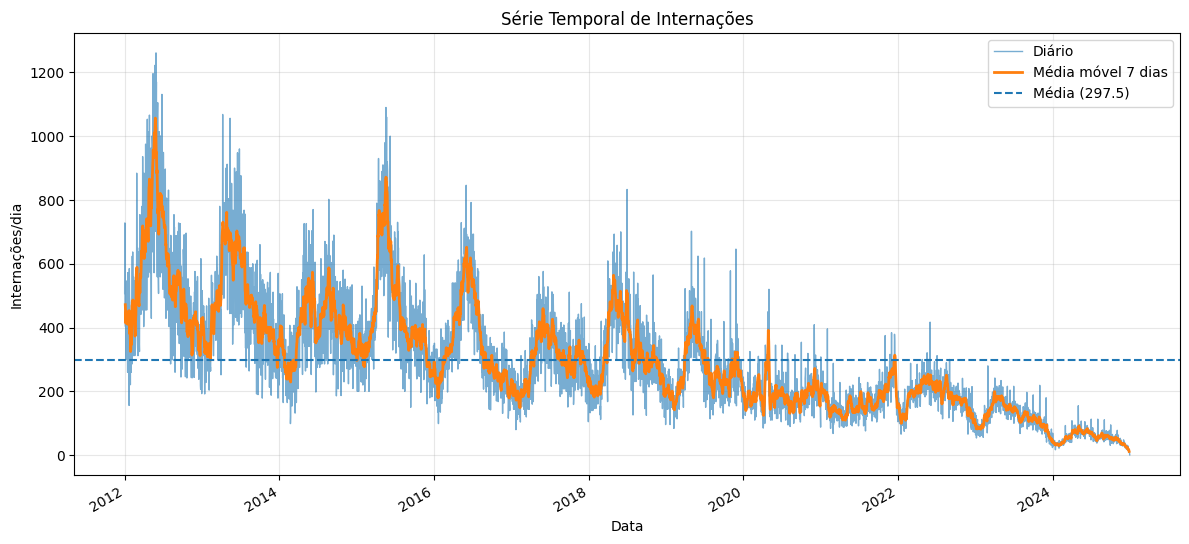

In [3]:
ts = df_unificado.set_index(pd.to_datetime(df_unificado['data_dia']))['y']

plt.figure(figsize=(12, 6))
plt.plot(ts.index, ts.values, label='Diário', alpha=0.6, linewidth=1)
plt.plot(ts.index, ts.rolling(7, center=True).mean(), label='Média móvel 7 dias', linewidth=2)
mean_val = ts.mean()
plt.axhline(mean_val, linestyle='--', linewidth=1.5, label=f'Média ({mean_val:.1f})')
plt.title('Série Temporal de Internações')
plt.xlabel('Data'); plt.ylabel('Internações/dia')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.gcf().autofmt_xdate()

## 4) Engenharia de *features* (médias móveis causais)
Cria colunas de médias móveis para poluentes/variáveis ambientais com defasagem causal para garantir ordenação temporal

In [4]:
df_unificado["data_dia"] = pd.to_datetime(df_unificado["data_dia"])
df_unificado = df_unificado.sort_values("data_dia").reset_index(drop=True)

specs = [
    ("o3",   150, 0),
    ("o3",   150, 3),
    ("o3",   150, 5),
    ("no",    60, 0),
    ("so2",  150, 3),
    ("so2",  150, 7),
    ("nox",   60, 0),
    ("no2",   30, 0),
    ("pm10",  30, 0),
    ("pm2_5",  7, 0),
    ("co",     3, 7),
]

for var, window, shift in specs:
    if var not in df_unificado.columns:
        continue
    col_name = f"{var}_r{window}_s{shift}_mean"
    df_unificado[col_name] = (
        df_unificado[var].shift(shift)
        .rolling(window=window, min_periods=window)
        .mean()
    )

print("Novas colunas criadas (amostra):")
print([c for c in df_unificado.columns if c.endswith('_mean')][:10])

Novas colunas criadas (amostra):
['roll7_mean', 'roll14_mean', 'roll30_mean', 'o3_r150_s0_mean', 'o3_r150_s3_mean', 'o3_r150_s5_mean', 'no_r60_s0_mean', 'so2_r150_s3_mean', 'so2_r150_s7_mean', 'nox_r60_s0_mean']


## 5) Funções auxiliares — calendário contínuo e imputação causal
Cria calendário diário sem buracos e **não** preenche o alvo (y).

In [5]:
def make_daily_frame(
    df: pd.DataFrame,
    date_col: str,
    target_col: str,
    ffill_limit: int = 14,
    categorical_cols: List[str] | None = None
) -> pd.DataFrame:
    """
    - Cria índice diário contínuo.
    - Adiciona colunas *_missing indicando onde faltou dado.
    - Faz forward-fill limitado nos preditores numéricos e categóricos.
    - NÃO altera o alvo (target_col).
    """
    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col], errors='coerce')
    data = data.sort_values(date_col).set_index(date_col)

    # índice diário completo
    full_idx = pd.date_range(data.index.min(), data.index.max(), freq='D')
    data = data.reindex(full_idx)

    if categorical_cols is None:
        categorical_cols = []

    # detecta numéricas, exceto o y
    num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in num_cols:
        num_cols.remove(target_col)

    # detecta categóricas explícitas
    cat_cols = [c for c in categorical_cols if c in data.columns]

    # flags de missing ANTES de preencher
    for c in num_cols + cat_cols:
        data[f"{c}_missing"] = data[c].isna().astype(int)

    # forward fill limitado (não usa info do futuro distante)
    for c in num_cols:
        data[c] = data[c].ffill(limit=ffill_limit)

    for c in cat_cols:
        data[c] = data[c].ffill(limit=min(3, ffill_limit))

    return data

## 6) Janelas causais (rolling window) → dataset tabular
Aplica janela deslizante e achata para colunas do tipo `feat_t-1`, `feat_t-2`, ...

In [6]:
def apply_rolling_window(
    time_series_array: np.ndarray,
    initial_time_step: int,
    max_time_step: int,
    window_size: int,
    target_idx: int
):
    """
    Cria janelas causais:
    X -> [amostras, janela, n_features]
    y -> [amostras] (valor de y imediatamente após a janela)
    """
    assert 0 <= target_idx < time_series_array.shape[1]
    assert initial_time_step >= 0
    assert max_time_step >= initial_time_step

    start = initial_time_step
    sub_windows = (
        start +
        np.expand_dims(np.arange(window_size), 0) +
        np.expand_dims(np.arange(max_time_step + 1), 0).T
    )

    # X3d
    X = time_series_array[sub_windows]

    # alvo é o próximo passo após a janela
    y = time_series_array[
        window_size:(max_time_step+window_size+1):1,
        target_idx
    ]

    idx_y_train_not_nan = np.where(~np.isnan(y))[0]
    assert len(idx_y_train_not_nan) == len(y), 'Há y NaN — ajuste construção de janelas.'
    _ = np.unique(np.where(np.isnan(X)))  # X pode ter NaN -> vamos imputar depois p/ LSTM

    return X, y


def rolling_to_tabular(
    df_windowed: pd.DataFrame,
    window_size: int,
    target_col: str,
    date_index: pd.DatetimeIndex
) -> Tuple[pd.DataFrame, np.ndarray, np.ndarray, List[str]]:
    """
    Converte a série multivariada em:
    - X_flat (2D) p/ modelos tabulares (RF)
    - y (1D) alvo
    - X_seq (3D) p/ modelos sequenciais (LSTM)
    - seq_cols (ordem das colunas originais nos canais da sequência)
    """
    cols = df_windowed.columns.tolist()
    target_idx = cols.index(target_col)

    A = df_windowed.to_numpy()
    max_ts = len(df_windowed) - window_size - 1

    X3d, y = apply_rolling_window(
        A,
        initial_time_step=0,
        max_time_step=max_ts,
        window_size=window_size,
        target_idx=target_idx
    )

    # Achata X3d -> X2d (lags explodidos) para RF
    ns, w, nf = X3d.shape
    X2d = X3d.reshape(ns, w * nf)

    names = []
    for lag in range(1, window_size+1):
        for c in cols:
            names.append(f"{c}_t-{lag}")

    idx = date_index[window_size:(max_ts+window_size+1)]
    X_flat = pd.DataFrame(X2d, columns=names, index=idx)

    return X_flat, y, X3d, cols

## 7) Métricas e pesos de recência
Funções utilitárias para avaliação e ponderação temporal.

In [7]:
def make_recency_weights(
    index: pd.DatetimeIndex,
    low: float = 0.5,
    high: float = 1.5
) -> pd.Series:
    """
    Gera pesos maiores para amostras mais recentes.
    """
    t = (index - index.min()).days.astype(float)
    w = low + (high - low) * (t - t.min()) / (t.max() - t.min() + 1e-9)
    return pd.Series(w, index=index).clip(lower=low, upper=high)


def smape(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return 100*np.mean(
        2*np.abs(yhat - y)/(np.abs(y)+np.abs(yhat)+1e-9)
    )


def wmape(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return 100*np.sum(np.abs(yhat - y))/np.sum(np.abs(y)+1e-9)


def evaluate_predictions(y_true, y_pred) -> Dict[str, float]:
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred),
        'WMAPE': wmape(y_true, y_pred),
    }

## 8) Seleção de features via Permutation Importance (para RF) *Permutation Importance*
Seleciona as `k` melhores variáveis no último *fold* (mais recente).

In [8]:
def select_top_features(
    X: pd.DataFrame,
    y: np.ndarray,
    pre: ColumnTransformer,
    n_splits: int = 4,
    random_state: int = 42,
    k: int = 8
) -> List[str]:
    """
    Treina RF simples no último fold (mais recente),
    calcula importance via permutação no conjunto de validação,
    e retorna as top-k features.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)

    base_rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=10,
        min_samples_split=10,
        max_features='sqrt',
        random_state=random_state,
        n_jobs=-1
    )

    ttr = TransformedTargetRegressor(
        regressor=base_rf,
        func=np.log1p,
        inverse_func=np.expm1
    )

    pipe = Pipeline([
        ('pre', pre),
        ('rf', ttr)
    ])

    folds = list(tscv.split(X))
    tr_idx, va_idx = folds[-1]  # último fold (mais recente)

    Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
    ytr, yva = y[tr_idx], y[va_idx]

    pipe.fit(Xtr, ytr)

    imp = permutation_importance(
        pipe,
        Xva,
        yva,
        n_repeats=10,
        random_state=random_state,
        scoring='neg_mean_absolute_error'
    )

    importances = pd.Series(
        imp.importances_mean,
        index=X.columns
    ).sort_values(ascending=False)

    return importances.head(k).index.tolist()

## 9) Random Forest + busca rápida de hiperparâmetros
Modelo com capacidade limitada para reduzir *overfitting*.

In [9]:
def tune_and_fit_rf_simplified(
    X: pd.DataFrame,
    y: np.ndarray,
    preprocessor: ColumnTransformer,
    n_splits: int = 5,
    random_state: int = 42
) -> Pipeline:
    """
    Pipeline(preprocess -> TTR(RandomForest)) +
    RandomizedSearchCV com validação temporal.
    """
    base_rf = RandomForestRegressor(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=10,
        min_samples_split=10,
        max_features='sqrt',
        bootstrap=True,
        n_jobs=-1,
        random_state=random_state
    )

    ttr = TransformedTargetRegressor(
        regressor=base_rf,
        func=np.log1p,
        inverse_func=np.expm1
    )

    pipe = Pipeline([
        ('pre', preprocessor),
        ('rf', ttr)
    ])

    param_dist = {
        'rf__regressor__n_estimators': [300, 400, 600],
        'rf__regressor__max_depth': [8, 12, 16],
        'rf__regressor__min_samples_leaf': [5, 10, 20],
        'rf__regressor__min_samples_split': [5, 10, 20],
        'rf__regressor__max_features': ['sqrt', 0.5],
    }

    tscv = TimeSeriesSplit(n_splits=n_splits)

    # pesos de recência dão mais importância aos dados mais novos
    rec_w = make_recency_weights(X.index, low=0.7, high=2).values

    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_dist,
        n_iter=12,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        random_state=random_state,
        refit=True,
        verbose=0
    )

    search.fit(X, y, rf__sample_weight=rec_w)

    return search.best_estimator_

## 10) Funções de inspeção e plot das previsões (RF)
Funções para auditar regras e visualizar observado × previsto.

In [10]:
def print_one_tree(
    model: Pipeline,
    feature_names: List[str],
    estimator_idx: int = 0
) -> None:
    """
    Imprime uma árvore individual do Random Forest
    (boa p/ interpretar regras).
    """
    rf = model.named_steps['rf'].regressor_
    tree = rf.estimators_[estimator_idx]

    txt = export_text(
        tree,
        feature_names=feature_names[:tree.n_features_in_]
    )
    print(txt)


def predict_and_plot_rf(
    model: Pipeline,
    X: pd.DataFrame,
    y: np.ndarray,
    title: str
) -> Dict:
    """
    Faz previsão com RF (via TransformedTargetRegressor),
    calcula métricas e gera gráfico Observado vs Previsto.
    """
    y_hat = model.predict(X)
    y_hat = np.clip(y_hat, 0, None)

    m = evaluate_predictions(y, y_hat)

    dfp = pd.DataFrame(
        {'y_true': y, 'y_pred': y_hat},
        index=X.index
    )

    plt.figure(figsize=(12,5))
    plt.plot(dfp.index, dfp['y_true'], label='Observado', lw=1.2)
    plt.plot(dfp.index, dfp['y_pred'], label='Previsto (RF)', lw=1.2)
    plt.title(title); plt.xlabel('Data'); plt.ylabel('Internações / dia')
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

    return {
        'metrics': m,
        'pred_df': dfp
    }

## 11) Preparação completa dos dados
(tratamento, janela causal, splits, seleção de features)
>>> Agora também retorna tensores 3D p/ a LSTM <<<

In [11]:
def prepare_rolling_dataset(
    df_unificado: pd.DataFrame,
    date_col: str = 'data_dia',
    target_col: str = 'y',
    categorical_cols: List[str] = ('Qualidade_do_Ar',),
    window_size: int = 14,
    test_size: float = 0.2,
    gap_days: int = 7,
    k_features: int = 12,
    random_state: int = 42
) -> Dict:
    """
    Gera todos os insumos:
      - base diária contínua com imputação forward limitada (make_daily_frame)
      - janelas causais (rolling_to_tabular)
      - split temporal treino/teste com folga (gap_days)
      - seleção de top-k features para RF
      - preprocessor final p/ RF
      - tensores 3D p/ LSTM (sem seleção de features)
    """

    # 1) Série contínua diária + imputação causal
    base = make_daily_frame(
        df_unificado,
        date_col=date_col,
        target_col=target_col,
        ffill_limit=14,
        categorical_cols=list(categorical_cols)
    )

    # 2) Remove colunas que possam vazar informação futura do alvo
    drop_regex = re.compile(
        r'^(y_?(lag|ma|mm|rolling|roll|shift|media|soma|sum))|(_lag\d+)$',
        re.IGNORECASE
    )
    cols_to_drop = [c for c in base.columns if drop_regex.search(c)]
    base = base.drop(columns=cols_to_drop, errors='ignore')

    # 3) Constrói dataset supervisionado (tabular e sequencial)
    feat_cols = [c for c in base.columns if c != target_col]

    X_full_tab, y_full, X_full_seq, seq_cols = rolling_to_tabular(
        base[feat_cols + [target_col]],
        window_size=window_size,
        target_col=target_col,
        date_index=base.index
    )

    # 4) Split temporal treino / teste com "folga" para evitar vazamento
    n = len(X_full_tab)
    cut = int(np.floor((1 - test_size) * n))

    train_idx = slice(0, max(cut - gap_days, 0))
    test_idx  = slice(cut, n)

    X_train_tab, y_train = X_full_tab.iloc[train_idx], y_full[train_idx]
    X_test_tab,  y_test  = X_full_tab.iloc[test_idx],  y_full[test_idx]

    X_train_seq = X_full_seq[train_idx]
    X_test_seq  = X_full_seq[test_idx]

    # 5) Setup de pré-processador provisório para RF (pra selecionar features)
    cat_cols = [
        c for c in X_train_tab.columns
        for base_c in categorical_cols
        if c.startswith(f"{base_c}_t-")
    ]
    num_cols = [c for c in X_train_tab.columns if c not in cat_cols]

    pre_tmp = ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_cols),
            (
                'cat',
                Pipeline([
                    ('imp', SimpleImputer(strategy='most_frequent')),
                    ('ohe', OneHotEncoder(handle_unknown='ignore'))
                ]),
                cat_cols
            ),
        ],
        remainder='drop'
    )

    # 6) Importância de features e top-k
    topk_raw = select_top_features(
        X_train_tab,
        y_train,
        pre_tmp,
        n_splits=4,
        random_state=random_state,
        k=k_features
    )

    # força alguns lags clássicos do alvo
    must = [
        f'y_t-{lag}'
        for lag in (1, 7, 14, 30)
        if f'y_t-{lag}' in X_train_tab.columns
    ]
    features_kept = list(dict.fromkeys(must + topk_raw))[:max(k_features, len(must))]

    # 7) Conjunto final p/ RF somente com features selecionadas
    X_train_sel = X_train_tab[features_kept]
    X_test_sel  = X_test_tab[features_kept]

    # 8) Pré-processador final do RF, agora apenas com features_kept
    cat_cols_sel = [
        c for c in features_kept
        for base_c in categorical_cols
        if c.startswith(f"{base_c}_t-")
    ]
    num_cols_sel = [c for c in features_kept if c not in cat_cols_sel]

    pre_sel = ColumnTransformer(
        transformers=[
            (
                'num',
                Pipeline([('imp', SimpleImputer(strategy='median'))]),
                num_cols_sel
            ),
            (
                'cat',
                Pipeline([
                    ('imp', SimpleImputer(strategy='most_frequent')),
                    ('ohe', OneHotEncoder(handle_unknown='ignore'))
                ]),
                cat_cols_sel
            ),
        ],
        remainder='drop'
    )

    return {
        # Para RF/tabular
        'X_train': X_train_sel,
        'y_train': y_train,
        'X_test':  X_test_sel,
        'y_test':  y_test,
        'preprocessor': pre_sel,
        'features_kept': features_kept,

        # Para LSTM/sequencial
        'X_train_seq': X_train_seq,   # shape: (n_train, window, n_feat)
        'X_test_seq':  X_test_seq,    # shape: (n_test , window, n_feat)
        'seq_feature_names': seq_cols,

        # Index temporal (útil p/ pesos e gráficos)
        'idx_train': X_train_sel.index,
        'idx_test':  X_test_sel.index,
    }

## 12) Funções auxiliares específicas da LSTM

In [12]:
def scale_seq_fit_transform(
    X_train_seq: np.ndarray,
    X_test_seq: np.ndarray
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, StandardScaler]:
    """
    Normaliza cada feature ao longo da janela usando apenas o treino.
    Passos:
      - Achata [amostra, janela, feat] -> [amostra*janela, feat]
      - Imputa NaN com mediana do treino por feature
      - Ajusta StandardScaler no treino e aplica no teste
    Retorna tensores float32 prontos p/ Keras.
    """
    n_train, w, f = X_train_seq.shape
    n_test,  w2, f2 = X_test_seq.shape
    assert (w, f) == (w2, f2), "Dimensão inconsistente treino/teste"

    Xtr2d = X_train_seq.reshape(n_train*w, f).astype('float64')
    Xte2d = X_test_seq.reshape(n_test*w2, f2).astype('float64')

    # imputação simples por mediana do treino
    med = np.nanmedian(Xtr2d, axis=0)

    inds = np.where(np.isnan(Xtr2d))
    if inds[0].size > 0:
        Xtr2d[inds] = med[inds[1]]

    inds2 = np.where(np.isnan(Xte2d))
    if inds2[0].size > 0:
        Xte2d[inds2] = med[inds2[1]]

    scaler = StandardScaler()
    Xtr_scaled2d = scaler.fit_transform(Xtr2d)
    Xte_scaled2d = scaler.transform(Xte2d)

    Xtr_scaled = Xtr_scaled2d.reshape(n_train, w, f).astype('float32')
    Xte_scaled = Xte_scaled2d.reshape(n_test,  w2, f2).astype('float32')

    return Xtr_scaled, Xte_scaled, med, scaler


# ==========================================
# 12) LSTM otimizada:
#     - 2 camadas LSTM empilhadas
#     - 3 camadas densas (com dropout)
#     - early stopping com mais paciência
#     - ReduceLROnPlateau
#     - sample_weight por recência
# ==========================================
def build_and_train_lstm_optimized(
    X_train_seq_scaled: np.ndarray,
    y_train: np.ndarray,
    idx_train: pd.DatetimeIndex,
    window_size: int,
    patience: int = 20,
    epochs: int = 200,
    batch_size: int = 32,
    random_state: int = 42,
):
    """
    Treina a LSTM otimizada. Detalhes:
      - arquitetura híbrida (2 LSTM + 3 Dense = 5 camadas ocultas totais)
      - usa log1p(y) como alvo interno
      - usa EarlyStopping(patience maior) + ReduceLROnPlateau
      - aplica pesos maiores para amostras recentes (sample_weight)
      - separa uma validação temporal do final ~10% do treino
    """
    tf.random.set_seed(random_state)

    n_samples, w, n_feat = X_train_seq_scaled.shape
    assert w == window_size, "window_size não bate com shape da sequência"

    # validação = último 10% do treino (ordem temporal)
    val_size = max(int(0.1 * n_samples), 1)
    train_end = n_samples - val_size

    X_tr = X_train_seq_scaled[:train_end]
    X_va = X_train_seq_scaled[train_end:]

    y_tr_raw = y_train[:train_end]
    y_va_raw = y_train[train_end:]

    # alvo interno em log1p
    y_tr = np.log1p(y_tr_raw).astype('float32')
    y_va = np.log1p(y_va_raw).astype('float32')

    # pesos de recência (idx_train está na ordem cronológica)
    rec_w_series = make_recency_weights(idx_train, low=0.7, high=1.3)
    w_full = rec_w_series.values.astype('float32')
    w_tr = w_full[:train_end]  # pesos só do conjunto de treino

    # Arquitetura híbrida:
    # - 2 LSTM (camadas temporais)
    # - depois empilhamos camadas densas com dropout
    # Isso conta como 5 camadas ocultas (2 LSTM + 3 Dense),
    # antes da camada final de saída escalar.
    model = keras.Sequential([
        layers.Input(shape=(window_size, n_feat)),
        layers.LSTM(128, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.2),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),

        layers.Dense(1),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss="mae",   # MAE em log1p(y)
        metrics=["mae", "mse"]
    )

    cb_early = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
        verbose=1,
    )
    cb_reduce = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1,
    )

    history = model.fit(
        X_tr,
        y_tr,
        validation_data=(X_va, y_va),
        epochs=epochs,
        batch_size=batch_size,
        sample_weight=w_tr,
        callbacks=[cb_early, cb_reduce],
        verbose=1
    )

    return model, history


def predict_and_plot_lstm(
    model: keras.Model,
    X_seq_scaled: np.ndarray,
    y_true: np.ndarray,
    idx_dates: pd.DatetimeIndex,
    title: str
) -> Dict:
    """
    Faz predição:
      - modelo retorna log1p(y_hat)
      - convertemos pra escala original com expm1
      - calcula métricas e plota Observado vs Previsto
    """
    y_hat_log = model.predict(X_seq_scaled).reshape(-1)
    y_hat = np.expm1(y_hat_log)
    y_hat = np.clip(y_hat, 0, None)

    m = evaluate_predictions(y_true, y_hat)

    dfp = pd.DataFrame(
        {'y_true': y_true, 'y_pred': y_hat},
        index=idx_dates
    )

    plt.figure(figsize=(12,5))
    plt.plot(dfp.index, dfp['y_true'], label='Observado', lw=1.2)
    plt.plot(dfp.index, dfp['y_pred'], label='Previsto (LSTM Otimizada)', lw=1.2)
    plt.title(title); plt.xlabel('Data'); plt.ylabel('Internações / dia')
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

    return {
        'metrics': m,
        'pred_df': dfp
    }

## 13) Pipeline principal - Random Forest

In [13]:
def run_pipeline_rf_rolling(
    df_unificado: pd.DataFrame,
    date_col: str = 'data_dia',
    target_col: str = 'y',
    categorical_cols: List[str] = ('Qualidade_do_Ar',),
    window_size: int = 14,   # RF continua com janela 14 (como antes)
    test_size: float = 0.2,
    gap_days: int = 7,
    k_features: int = 12,
    random_state: int = 42
) -> Dict:
    """
    Pipeline completo do Random Forest:
      - prepara dados
      - faz tuning do RF
      - avalia treino e teste
      - imprime uma árvore do ensemble
    """
    prepared = prepare_rolling_dataset(
        df_unificado=df_unificado,
        date_col=date_col,
        target_col=target_col,
        categorical_cols=categorical_cols,
        window_size=window_size,
        test_size=test_size,
        gap_days=gap_days,
        k_features=k_features,
        random_state=random_state,
    )

    X_train_tab = prepared['X_train']
    y_train     = prepared['y_train']
    X_test_tab  = prepared['X_test']
    y_test      = prepared['y_test']
    pre_sel     = prepared['preprocessor']
    topk        = prepared['features_kept']

    # tuning + fit final
    best_model = tune_and_fit_rf_simplified(
        X_train_tab,
        y_train,
        preprocessor=pre_sel,
        n_splits=5,
        random_state=random_state
    )

    # avaliação treino
    train_res = predict_and_plot_rf(
        best_model,
        X_train_tab,
        y_train,
        'Real x Previsto — RF (Treino)'
    )

    # avaliação teste
    test_res  = predict_and_plot_rf(
        best_model,
        X_test_tab,
        y_test,
        'Real x Previsto — RF (Teste)'
    )

    print('\n===== Árvore 0 do RF (resumo) =====')
    print_one_tree(
        best_model,
        feature_names=X_train_tab.columns.tolist(),
        estimator_idx=0
    )

    return {
        'model': best_model,
        'features_kept': topk,
        'train_metrics': train_res['metrics'],
        'test_metrics':  test_res['metrics'],
        'train_pred_df': train_res['pred_df'],
        'test_pred_df':  test_res['pred_df'],
    }

## 14) Pipeline principal - LSTM profunda (5 camadas)

In [14]:
def run_pipeline_lstm_rolling_optimized(
    df_unificado: pd.DataFrame,
    date_col: str = 'data_dia',
    target_col: str = 'y',
    categorical_cols: List[str] = ('Qualidade_do_Ar',),
    window_size: int = 30,   # <-- janela maior para capturar dinâmicas mais longas
    test_size: float = 0.2,
    gap_days: int = 7,
    random_state: int = 42
) -> Dict:
    """
    Pipeline completo da LSTM otimizada:
      - usa a MESMA preparação de dados (mesmo split temporal)
        só que com uma janela maior (ex: 30 dias)
      - normaliza sequências
      - treina LSTM híbrida (2 LSTM + 3 Dense)
        com early stopping + ReduceLROnPlateau
        e sample_weight dando mais peso para amostras recentes
      - avalia em treino e teste (convertendo de volta a escala original de y)
    """
    prepared = prepare_rolling_dataset(
        df_unificado=df_unificado,
        date_col=date_col,
        target_col=target_col,
        categorical_cols=categorical_cols,
        window_size=window_size,
        test_size=test_size,
        gap_days=gap_days,
        k_features=30,           # RF usa isso; para LSTM não é crítico,
        random_state=random_state,
    )

    X_train_seq = prepared['X_train_seq']    # (n_train, window, n_feat)
    X_test_seq  = prepared['X_test_seq']     # (n_test , window, n_feat)
    y_train     = prepared['y_train']        # (n_train,)
    y_test      = prepared['y_test']         # (n_test,)
    idx_train   = prepared['idx_train']      # DatetimeIndex treino
    idx_test    = prepared['idx_test']       # DatetimeIndex teste

    # Normaliza as sequências (fit só no treino)
    X_train_scaled, X_test_scaled, medians_used, scaler_seq = scale_seq_fit_transform(
        X_train_seq,
        X_test_seq
    )

    # Treina LSTM otimizada
    lstm_model, history = build_and_train_lstm_optimized(
        X_train_scaled,
        y_train,
        idx_train=idx_train,
        window_size=window_size,
        patience=20,
        epochs=200,
        batch_size=32,
        random_state=random_state,
    )

    # Avaliação treino
    train_res = predict_and_plot_lstm(
        lstm_model,
        X_train_scaled,
        y_train,
        idx_train,
        title='Real x Previsto — LSTM Otimizada (Treino)'
    )

    # Avaliação teste
    test_res = predict_and_plot_lstm(
        lstm_model,
        X_test_scaled,
        y_test,
        idx_test,
        title='Real x Previsto — LSTM Otimizada (Teste)'
    )

    return {
        'model': lstm_model,
        'scaler_seq': scaler_seq,
        'imputer_medians': medians_used,
        'train_metrics': train_res['metrics'],
        'test_metrics':  test_res['metrics'],
        'train_pred_df': train_res['pred_df'],
        'test_pred_df':  test_res['pred_df'],
    }

## 15) Exemplo de uso

In [15]:
df_unificado2 = (
    df_unificado[df_unificado.get('year', 9999) <= 2021]
    if 'year' in df_unificado.columns
    else df_unificado.copy()
)

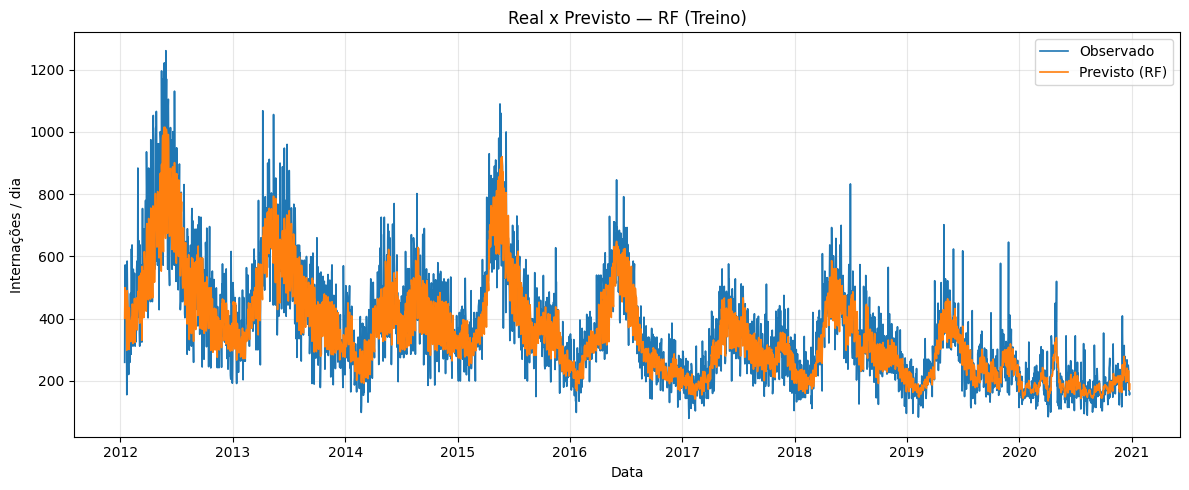

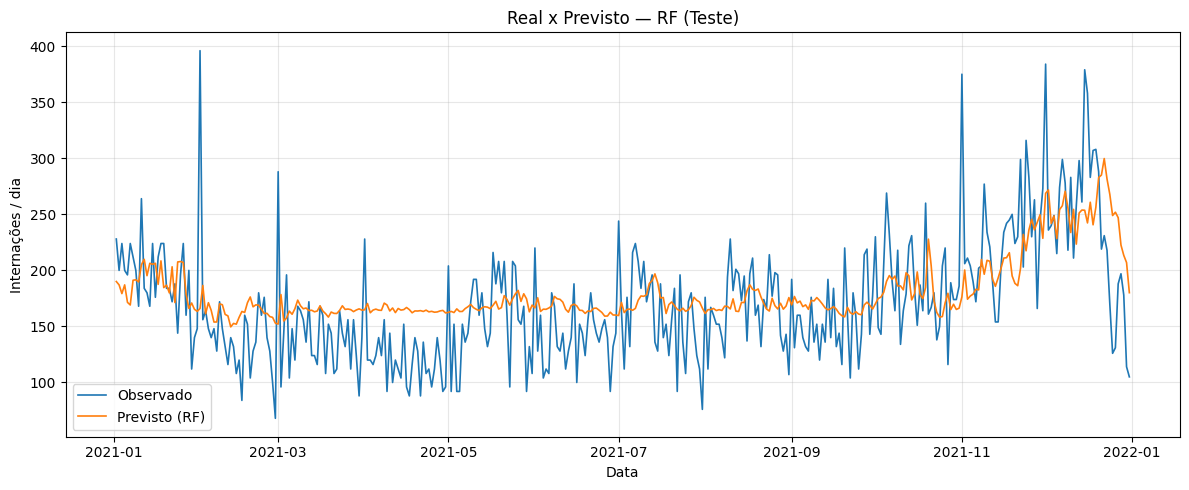


===== Árvore 0 do RF (resumo) =====
|--- roll14_mean_t-12 <= 316.79
|   |--- roll7_mean_t-11 <= 240.64
|   |   |--- roll14_mean_t-13 <= 190.32
|   |   |   |--- roll7_mean_t-5 <= 178.00
|   |   |   |   |--- roll14_std_t-13 <= 29.57
|   |   |   |   |   |--- value: [5.05]
|   |   |   |   |--- roll14_std_t-13 >  29.57
|   |   |   |   |   |--- roll30_std_t-10 <= 57.55
|   |   |   |   |   |   |--- roll30_std_t-10 <= 38.09
|   |   |   |   |   |   |   |--- value: [5.45]
|   |   |   |   |   |   |--- roll30_std_t-10 >  38.09
|   |   |   |   |   |   |   |--- y_t-14 <= 178.00
|   |   |   |   |   |   |   |   |--- roll30_std_t-14 <= 46.92
|   |   |   |   |   |   |   |   |   |--- value: [5.42]
|   |   |   |   |   |   |   |   |--- roll30_std_t-14 >  46.92
|   |   |   |   |   |   |   |   |   |--- roll7_mean_t-14 <= 169.64
|   |   |   |   |   |   |   |   |   |   |--- value: [5.06]
|   |   |   |   |   |   |   |   |   |--- roll7_mean_t-14 >  169.64
|   |   |   |   |   |   |   |   |   |   |--- value: [5.2

: 

In [ ]:
out_rf = run_pipeline_rf_rolling(
    df_unificado2,
    date_col='data_dia',
    target_col='y',
    categorical_cols=('Qualidade_do_Ar',),
    window_size=14,    # janela curta pro RF, como antes
    test_size=0.1,
    gap_days=7,
    k_features=30,
    random_state=42
)

print('\n[RF] Features usadas:', out_rf['features_kept'])
print('[RF] Métricas Treino:', out_rf['train_metrics'])
print('[RF] Métricas Teste :', out_rf['test_metrics'])

Epoch 1/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 2.6184 - mae: 2.7252 - mse: 11.2152 - val_loss: 0.6004 - val_mae: 0.6004 - val_mse: 0.4531 - learning_rate: 5.0000e-04
Epoch 2/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 1.0664 - mae: 1.1067 - mse: 1.9271 - val_loss: 0.5693 - val_mae: 0.5693 - val_mse: 0.4218 - learning_rate: 5.0000e-04
Epoch 3/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.9310 - mae: 0.9633 - mse: 1.4658 - val_loss: 0.4024 - val_mae: 0.4024 - val_mse: 0.2592 - learning_rate: 5.0000e-04
Epoch 4/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.9233 - mae: 0.9577 - mse: 1.4311 - val_loss: 0.6153 - val_mae: 0.6153 - val_mse: 0.4975 - learning_rate: 5.0000e-04
Epoch 5/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.8598 - mae: 0.8914 - mse: 1.2534 - val_loss: 0.3945 - val_mae: 0.3945 - val_mse: 0.2366 - learning_rate: 5.0000e-04
Epoch 6/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.8481 - mae: 0.8781 - mse: 1.1800 - val_loss: 0.

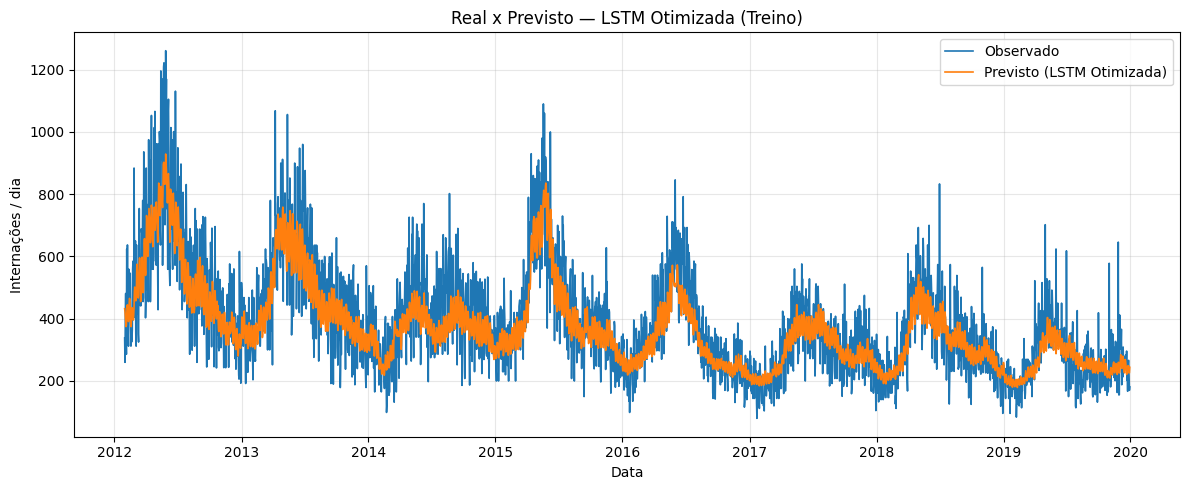

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


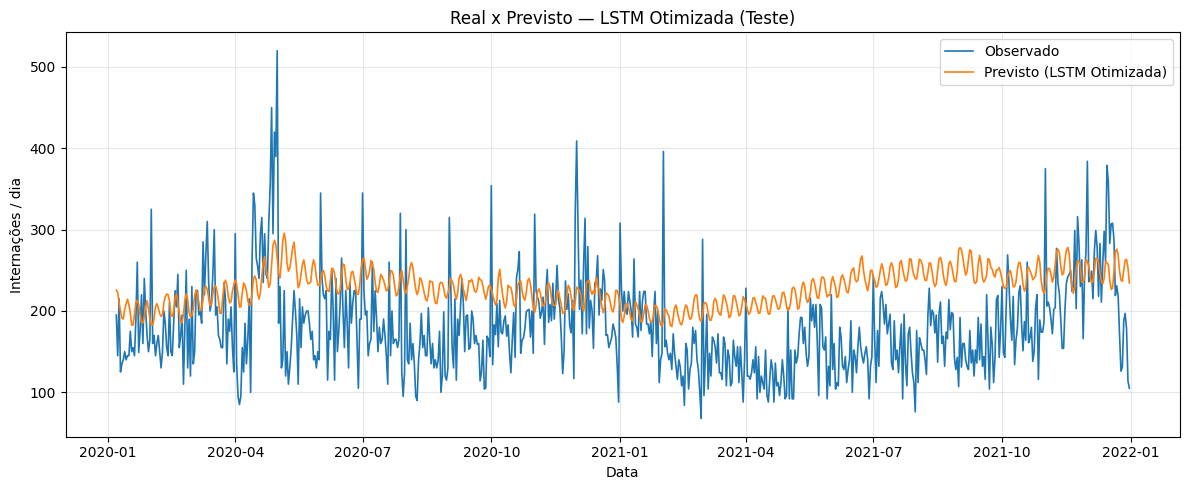


[LSTM Otimizada] Métricas Treino: {'MAE': 70.05793191651826, 'RMSE': np.float64(94.25688238459871), 'R2': 0.7188332419022025, 'sMAPE': np.float64(18.43086539657845), 'WMAPE': np.float64(17.837341325050584)}
[LSTM Otimizada] Métricas Teste : {'MAE': 63.660598081391434, 'RMSE': np.float64(74.51004512383491), 'R2': -0.6401163554289546, 'sMAPE': np.float64(32.88708955191826), 'WMAPE': np.float64(35.300725541131875)}


In [17]:
out_lstm = run_pipeline_lstm_rolling_optimized(
    df_unificado2,
    date_col='data_dia',
    target_col='y',
    categorical_cols=('Qualidade_do_Ar',),
    window_size=30,    # janela maior para capturar dinâmicas mais longas
    test_size=0.2,
    gap_days=7,
    random_state=42
)

print('\n[LSTM Otimizada] Métricas Treino:', out_lstm['train_metrics'])
print('[LSTM Otimizada] Métricas Teste :', out_lstm['test_metrics'])